# AI-Powered Visual Defect Detection System

## Convolutional Neural Network (CNN) Model

## Import Required Libraries

In [1]:
import os
import torch
import torchvision

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt

## Check PyTorch Configuration

In [2]:
print("PyTorch Version:", torch.__version__)

print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.12.1+cpu
CUDA Available: False


## Define Image Transformations

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Load Training and Validation Data

In [4]:
train_dataset = datasets.ImageFolder(
    "../Dataset/train/images",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "../Dataset/validation/images",
    transform=transform
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 1440
Validation Images: 360


## Create DataLoaders

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 45
Validation Batches: 12


## Inspect Training Batch

In [6]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Label Batch Shape: torch.Size([32])


## Visualizing Training Images

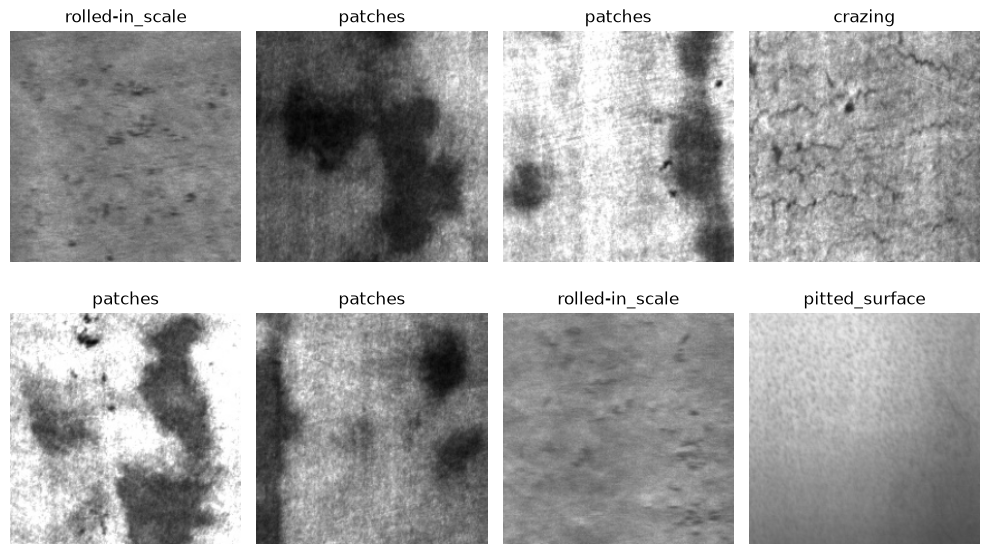

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(10, 6))

for i in range(8):
    img = images[i].permute(1, 2, 0)

    axes[i // 4, i % 4].imshow(img)
    axes[i // 4, i % 4].set_title(
        train_dataset.classes[labels[i]]
    )
    axes[i // 4, i % 4].axis("off")

plt.tight_layout()
plt.show()

## Define CNN Architecture

In [10]:
class DefectCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = DefectCNN()

print(model)

DefectCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


## Define Loss Function and Optimizer

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Training Configuration

In [13]:
epochs = 10

train_losses = []
train_accuracies = []

## Model Training

In [14]:
for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.4579 Accuracy: 39.72%
Epoch [2/10] Loss: 1.0159 Accuracy: 64.44%
Epoch [3/10] Loss: 0.7400 Accuracy: 75.00%
Epoch [4/10] Loss: 0.5971 Accuracy: 79.38%
Epoch [5/10] Loss: 0.5333 Accuracy: 82.15%
Epoch [6/10] Loss: 0.3691 Accuracy: 87.01%
Epoch [7/10] Loss: 0.2801 Accuracy: 91.74%
Epoch [8/10] Loss: 0.2467 Accuracy: 91.94%
Epoch [9/10] Loss: 0.2577 Accuracy: 92.08%
Epoch [10/10] Loss: 0.2255 Accuracy: 92.64%


## Training Performance

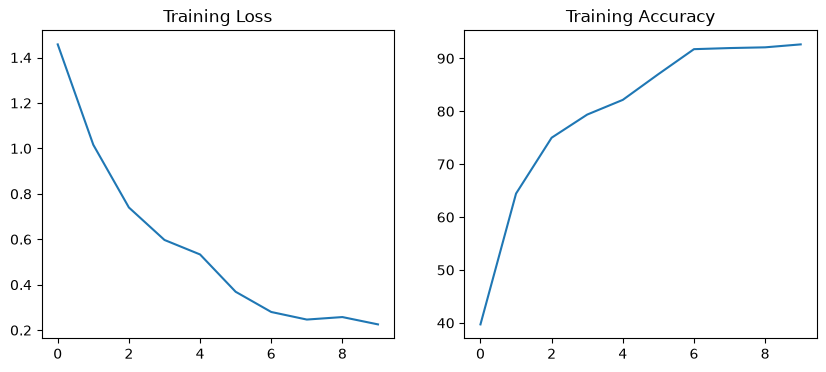

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")

plt.show()

## Model Evaluation

In [16]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

validation_accuracy = 100 * correct / total

print(
    f"Validation Accuracy: "
    f"{validation_accuracy:.2f}%"
)

Validation Accuracy: 74.44%


In [17]:
torch.save(
    model.state_dict(),
    "../models/cnn_baseline.pth"
)